In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'


In [2]:
 
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'
df_time =pd.read_csv('tables/time_maximum_groundingline_BMB.csv')
# Generate loop_info DataFrame

In [3]:
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

In [13]:
models=[]
paths =[]
exps =[]
region_names = ['Amundsen','Ross','Filchner_Ronne']
dic_sectors ={}
dic_sectors ['Amundsen']=np.array([4])
dic_sectors ['Ross']=np.array([2,6])
dic_sectors ['Filchner_Ronne']=np.array([5,11])
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
for j in range(1,4):
    df['region_'+str(j)] =0
for key in dic_sectors.keys():
    df[key] = 0
    
df_n = df.copy()
df_org = df.copy()

variable3 = 'groundingline_zone_area'
variable2 = 'groundingline_bmb'
variable1 = 'groundingline_thermal_forcing'
factor = -1* 365.25 * 24 * 3600/900
pth = pth_imip6hack
#         df2['sector_'+str(j)].iloc[i] = x[:50].max()

In [14]:
dic_area_of_interest ={}
dic_area_of_interest['AIS']= ['']
# dic_area_of_interest['WestAntarctica'] = ['_region_1']
# dic_area_of_interest['EastAntarctica'] = ['_region_2']
# dic_area_of_interest['Peninsula'] = ['_region_3']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['Filchner_Ronne'] = ['_sector_5','_sector_11']
      
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']
keys = ['AIS', 'Amundsen', 'Filchner_Ronne', 'Ross']
keys[1:]

['Amundsen', 'Filchner_Ronne', 'Ross']

In [15]:
df_time


,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,AIS,region_1,region_2,region_3,Amundsen,Ross,Filchner_Ronne,WestAntarctica,EastAntarctica,Peninsula
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,2202,2291,2298,2291,2287,2262,2278,...,2284,2291,2272,2209,2291,2291,2284,2291,2272,2209
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,2107,2265,2114,2280,2195,2227,2293,...,2233,2237,2119,2073,2280,2265,2195,2237,2119,2073
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,2219,2292,2114,2299,2285,2247,2278,...,2291,2291,2209,2116,2299,2292,2291,2291,2209,2116
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,2146,2231,2109,2230,2287,2205,2250,...,2119,2291,2119,2086,2230,2231,2121,2291,2119,2086
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,2187,2231,2086,2299,2232,2165,2292,...,2232,2232,2119,2086,2299,2231,2091,2232,2119,2086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,2164,2296,2068,2278,2210,2100,2284,...,2295,2213,2109,2033,2278,2296,2110,2213,2109,2033
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,2162,2297,2068,2299,2207,2100,2243,...,2203,2203,2109,2033,2299,2297,2207,2203,2109,2033
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,2170,2043,2068,2286,2216,2101,2284,...,2286,2286,2109,2033,2286,2043,2109,2286,2109,2033
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,2169,2043,2068,2299,2213,2101,2299,...,2109,2218,2109,2033,2299,2043,2109,2218,2109,2033


In [16]:
for i in range (df.shape[0]):
    
    
    #load the datasets:
    pth_way = f'{pth}/{df.iloc[i].Experiment}/groundingline_corridor32/computed_{variable2}_corr_32_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    
    pth_area =  f'{pth}/{df.iloc[i].Experiment}/groundingline_corridor32/computed_{variable3}_corr_32_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    pth_tf = f'{pth}/{df.iloc[i].Experiment}/groundingline_corridor32/computed_{variable1}_corr_32_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
   
    # Melting
    d = xr.open_dataset(pth_way,decode_times=False )
    # Area
    d2 = xr.open_dataset(pth_area,decode_times=False )
    #thermal forcing 
    d3 = xr.open_dataset(pth_tf,decode_times=False )
    
    
    ###### start with AIS
  
    t_max = df_time.iloc[i].AIS
    t_max = np.min([t_max,2100])

    tmin =np.where( d.time.values==t_max)[0][0]
    nm =dic_area_of_interest['AIS'][0]
 
    #melting per area
    y= d[f'{variable2}{nm}'].values[:tmin]*factor/d2[f'{variable3}{nm}'].values[:tmin]#avg bmb
    x = d3[f'{variable1}{nm}'].values[:tmin] #thermal forcign

    if len(x)>1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        df['AIS'].iloc[i]= slope
        df_n['AIS'].iloc[i]= intercept
        
        
    else:
        df['AIS'].iloc[i]= np.nan
        df_n['AIS'].iloc[i]= np.nan
    
    #all the sectors:
    for j in range(1,19):
        t_max = df_time.iloc[i]['sector_'+str(j)]
        t_max = np.min([t_max,2100])

    
        tmin =np.where( d.time.values==t_max)[0][0]
        nm = '_sector_'+str(j)
        #melting per area
        y= d[f'{variable2}{nm}'].values[:tmin]*factor/d2[f'{variable3}{nm}'].values[:tmin]#avg bmb
        x = d3[f'{variable1}{nm}'].values[:tmin] #thermal forcign

        mnan1 = np.isnan(y)
        mnan2 = np.isnan(x)
        mnan = mnan1 | mnan2
    
        if len(x[~mnan])>1:
            slope, intercept, r_value, p_value, std_err = linregress(x[~mnan], y[~mnan])
        
       
            df['sector_'+str(j)].iloc[i] = slope
            df_n['sector_'+str(j)].iloc[i] = intercept
        
        else:
            df['sector_'+str(j)].iloc[i] = np.nan
            df_n['sector_'+str(j)].iloc[i] = np.nan
            
    #all the regions
    for j in range(1,4):
        t_max = df_time.iloc[i]['region_'+str(j)]
        t_max = np.min([t_max,2100])

    
        tmin =np.where( d.time.values==t_max)[0][0]
        nm = '_region_'+str(j)
        #melting per area
        y= d[f'{variable2}{nm}'].values[:tmin]*factor/d2[f'{variable3}{nm}'].values[:tmin]#avg bmb
        x = d3[f'{variable1}{nm}'].values[:tmin] #thermal forcign

        mnan1 = np.isnan(y)
        mnan2 = np.isnan(x)
        mnan = mnan1 | mnan2


        if len(x[~mnan])>1:
            slope, intercept, r_value, p_value, std_err = linregress(x[~mnan], y[~mnan])
        
       
            df['region_'+str(j)].iloc[i] = slope
            df_n['region_'+str(j)].iloc[i] = intercept
        
        else:
            df['region_'+str(j)].iloc[i] = np.nan
            df_n['region_'+str(j)].iloc[i] = np.nan
            
#     #specific region,combination of sectors: amundsen,ross, Fris
    for key in keys[1:]:

        t_max = 2200
        for nam in dic_area_of_interest[key]:
            t_max1 = df_time.iloc[i][nam[1:]]
            
            t_max = np.min([t_max,t_max1])
           
            
    
        tmin =np.where( d.time.values==t_max)[0][0]
       
        #mcreat ys areas etc
        the_ys = np.zeros((len(dic_area_of_interest[key]),tmin))
        the_areas = np.zeros((len(dic_area_of_interest[key]),tmin))
        the_tfs = np.zeros((len(dic_area_of_interest[key]),tmin))
   
        for k,nm in enumerate(dic_area_of_interest[key]):
            the_ys[k,:] =d[f'{variable2}{nm}'].values[:tmin].copy()*factor
        
            the_areas[k,:]=d2[f'{variable3}{nm}'].values[:tmin].copy()
            
            the_tfs[k,:]=d3[f'{variable1}{nm}'].values[:tmin].copy()*the_areas[k,:].copy()
        y_all = np.sum(the_ys ,axis =0)
        area = np.sum( the_areas,axis = 0)
        y = y_all.copy()/area.copy() #gives average bmb timline
            
        TF = np.sum( the_tfs,axis = 0)/area #gives average thermal foricng line
        x = TF.copy()
        mnan1 = np.isnan(y)
        mnan2 = np.isnan(x)
        mnan = mnan1 | mnan2

        if len(x[~mnan])>1:
                
            print(f' NO to some nans!{i} at {df.iloc[i].Model}')
                
            slope, intercept, r_value, p_value, std_err = linregress(x[~mnan], y[~mnan])


            df[key].iloc[i] = slope
            df_n[key].iloc[i] = intercept
                
        else:
            print('all nans',df.iloc[i].Model)
            df[key].iloc[i] = np.nan
            df_n[key].iloc[i] =np.nan
                
     
            
            
            

df.to_csv('tables/linear_meltsensetivity_groundingline_from_BMB_max_time2100.csv', index=False)
df_n.to_csv('tables/linear_meltsensetivity_groundingline_from_BMB_max_intercept_time2100.csv', index=False)

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/1839920370.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AIS'].iloc[i]= slope
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/1839920370.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_n['AIS'].iloc[i]= intercept
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/1839920370.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-cop

 NO to some nans!0 at DC_ISSM
 NO to some nans!0 at DC_ISSM
 NO to some nans!0 at DC_ISSM
 NO to some nans!1 at IGE_ElmerIce
 NO to some nans!1 at IGE_ElmerIce
 NO to some nans!1 at IGE_ElmerIce
 NO to some nans!2 at ILTS_SICOPOLIS
 NO to some nans!2 at ILTS_SICOPOLIS
 NO to some nans!2 at ILTS_SICOPOLIS
 NO to some nans!3 at LSCE_GRISLI2
 NO to some nans!3 at LSCE_GRISLI2
 NO to some nans!3 at LSCE_GRISLI2
 NO to some nans!4 at LSCE_GRISLI
 NO to some nans!4 at LSCE_GRISLI
 NO to some nans!4 at LSCE_GRISLI
 NO to some nans!5 at NCAR_CISM1
 NO to some nans!5 at NCAR_CISM1
 NO to some nans!5 at NCAR_CISM1
 NO to some nans!6 at NCAR_CISM2
 NO to some nans!6 at NCAR_CISM2
 NO to some nans!6 at NCAR_CISM2
 NO to some nans!7 at NORCE_CISM2-MAR364-ERA-t1
 NO to some nans!7 at NORCE_CISM2-MAR364-ERA-t1
 NO to some nans!7 at NORCE_CISM2-MAR364-ERA-t1
 NO to some nans!8 at NORCE_CISM3-MAR364-ERA-t1-local
 NO to some nans!8 at NORCE_CISM3-MAR364-ERA-t1-local
 NO to some nans!8 at NORCE_CISM3-MAR

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/1839920370.py:49: RuntimeWarning: invalid value encountered in divide
  y= d[f'{variable2}{nm}'].values[:tmin]*factor/d2[f'{variable3}{nm}'].values[:tmin]#avg bmb
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/1839920370.py:121: RuntimeWarning: invalid value encountered in divide
  y = y_all.copy()/area.copy() #gives average bmb timline


 NO to some nans!66 at VUW_PISM1_s4
 NO to some nans!66 at VUW_PISM1_s4
 NO to some nans!66 at VUW_PISM1_s4
 NO to some nans!67 at VUW_PISM2
 NO to some nans!67 at VUW_PISM2
 NO to some nans!67 at VUW_PISM2
 NO to some nans!68 at VUW_PISM2_s1
 NO to some nans!68 at VUW_PISM2_s1
 NO to some nans!68 at VUW_PISM2_s1
 NO to some nans!69 at VUW_PISM2_s2
 NO to some nans!69 at VUW_PISM2_s2
 NO to some nans!69 at VUW_PISM2_s2
 NO to some nans!70 at VUW_PISM2_s3
 NO to some nans!70 at VUW_PISM2_s3
 NO to some nans!70 at VUW_PISM2_s3
 NO to some nans!71 at VUW_PISM2_s4
 NO to some nans!71 at VUW_PISM2_s4
 NO to some nans!71 at VUW_PISM2_s4
 NO to some nans!72 at DC_ISSM
 NO to some nans!72 at DC_ISSM
 NO to some nans!72 at DC_ISSM
 NO to some nans!73 at IGE_ElmerIce
 NO to some nans!73 at IGE_ElmerIce
 NO to some nans!73 at IGE_ElmerIce
 NO to some nans!74 at ILTS_SICOPOLIS
 NO to some nans!74 at ILTS_SICOPOLIS
 NO to some nans!74 at ILTS_SICOPOLIS
 NO to some nans!75 at LSCE_GRISLI2
 NO to som

 NO to some nans!138 at VUW_PISM1_s4
 NO to some nans!138 at VUW_PISM1_s4
 NO to some nans!138 at VUW_PISM1_s4
 NO to some nans!139 at VUW_PISM2
 NO to some nans!139 at VUW_PISM2
 NO to some nans!139 at VUW_PISM2
 NO to some nans!140 at VUW_PISM2_s1
 NO to some nans!140 at VUW_PISM2_s1
 NO to some nans!140 at VUW_PISM2_s1
 NO to some nans!141 at VUW_PISM2_s2
 NO to some nans!141 at VUW_PISM2_s2
 NO to some nans!141 at VUW_PISM2_s2
 NO to some nans!142 at VUW_PISM2_s3
 NO to some nans!142 at VUW_PISM2_s3
 NO to some nans!142 at VUW_PISM2_s3
 NO to some nans!143 at VUW_PISM2_s4
 NO to some nans!143 at VUW_PISM2_s4
 NO to some nans!143 at VUW_PISM2_s4


In [18]:
df

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_16,sector_17,sector_18,AIS,region_1,region_2,region_3,Amundsen,Ross,Filchner_Ronne
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,0.435411,0.214260,0.425074,0.713017,0.464054,0.251973,0.465355,...,0.210374,0.370985,0.432109,0.444736,0.425915,0.460354,0.379682,0.638737,0.260105,0.357942
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,0.322267,0.181717,0.786834,0.266665,0.478446,0.277667,1.926137,...,3.674741,2.160682,0.697846,0.680004,0.422514,0.863849,2.006493,0.317671,0.257382,0.569460
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,0.818279,0.358286,0.786123,1.551819,0.732159,0.358444,0.734825,...,0.282275,0.531286,0.808328,0.723718,0.717683,0.727248,0.630188,2.204738,0.466582,0.691939
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,0.326522,0.168928,0.425150,0.668684,0.356939,0.167188,0.349228,...,0.195428,0.284767,0.294122,0.332502,0.320436,0.347582,0.248327,0.835012,0.308846,0.370864
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,0.310077,0.173027,0.418869,0.779008,0.367120,0.181590,0.331758,...,0.174823,0.237983,0.218675,0.324099,0.319883,0.338867,0.165836,0.873662,0.269477,0.316130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,2.053818,0.414054,2.161292,2.169963,1.498976,0.783616,-0.069498,...,1.008201,1.054272,1.816428,1.295703,1.196787,1.180517,1.041307,1.660335,0.494821,1.833078
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,1.980682,0.443797,2.169802,2.173071,1.510023,0.805164,1.241076,...,0.994635,0.851492,1.839013,1.345214,1.236414,1.233916,1.007801,1.677685,0.525829,1.840690
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,1.785737,1.275025,2.141656,1.957716,1.527431,0.772716,0.624897,...,1.288780,1.078065,1.752373,1.299997,1.194337,1.166675,1.057039,1.576976,1.239963,1.830481
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,1.725743,1.164164,2.186094,2.237354,1.472418,0.777729,0.127241,...,1.261299,1.031260,1.785352,1.346459,1.218173,1.228633,1.009932,1.574774,1.139462,1.811497


In [19]:
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
df_ms = pd.read_csv('./tables/linear_meltsensetivity_groundingline_from_BMB_max.csv')
df_ms_n = pd.read_csv('./tables/linear_meltsensetivity_groundingline_from_BMB_max_intercept.csv')
df_ms['WestAntarctica'] = df_ms['region_1']
df_ms['EastAntarctica'] = df_ms['region_2']
df_ms['Peninsula'] = df_ms['region_3']
df_ms_n['WestAntarctica'] = df_ms_n['region_1']
df_ms_n['EastAntarctica'] = df_ms_n['region_2']
df_ms_n['Peninsula'] = df_ms_n['region_3']

df_time['WestAntarctica'] = df_time['region_1']
df_time['EastAntarctica'] = df_time['region_2']
df_time['Peninsula'] = df_time['region_3']

In [20]:
dic_area_of_interest ={}
dic_area_of_interest['AIS']= ['']
dic_area_of_interest['WestAntarctica'] = ['_region_1']
dic_area_of_interest['EastAntarctica'] = ['_region_2']
dic_area_of_interest['Peninsula'] = ['_region_3']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['Filchner_Ronne'] = ['_sector_5','_sector_11']
      
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']

In [21]:
fpath='./figs/linear_ms_groundingline_until_maxBMB_time2100/'
fname='linear_ms_groundingline'
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")
variable3 = 'groundingline_zone_area'
variable2 = 'groundingline_bmb'
variable1 = 'groundingline_thermal_forcing'
factor = -1* 365.25 * 24 * 3600/900
pth = pth_imip6hack

df_org = df_ms

The path './figs/linear_ms_groundingline_until_maxBMB_time2100/' already exists.


LSCE_GRISLI
NORCE_CISM4-MAR364-ERA-t1
NORCE_CISM4-MAR364-JRA-t1


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/466459769.py:92: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/466459769.py:92: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/466459769.py:92: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/466459769.py:92: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_45821/466459769.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot 

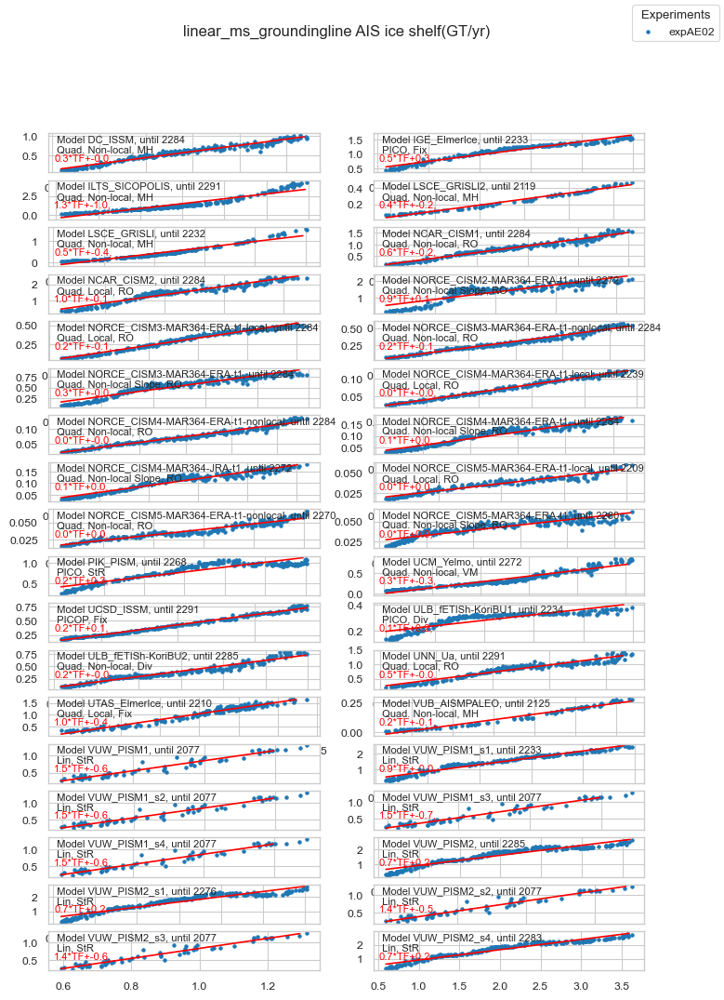

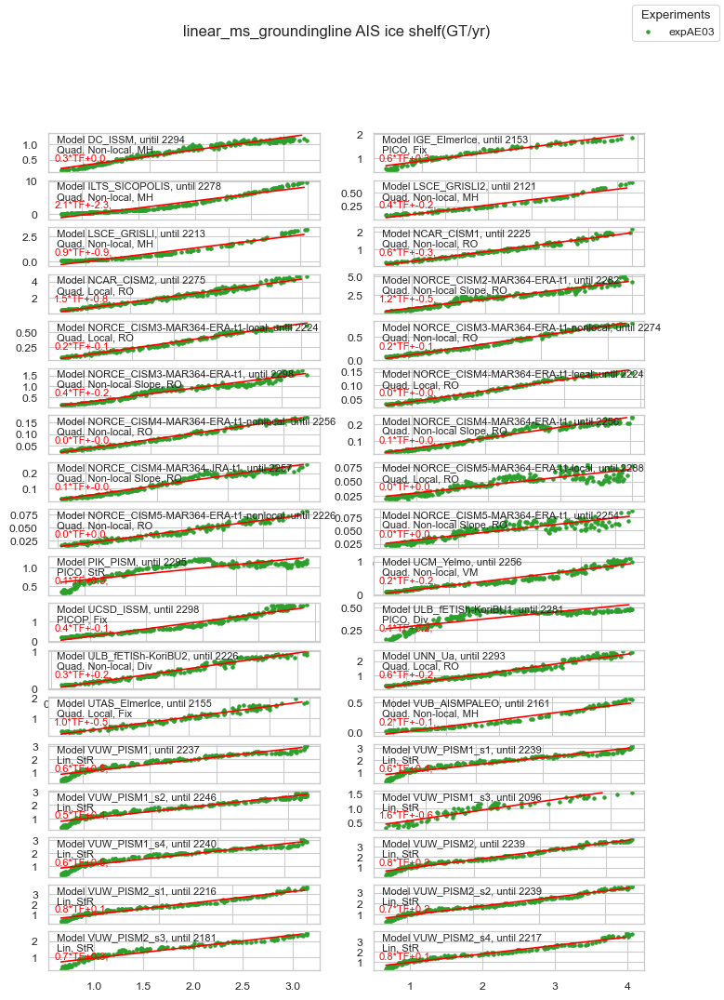

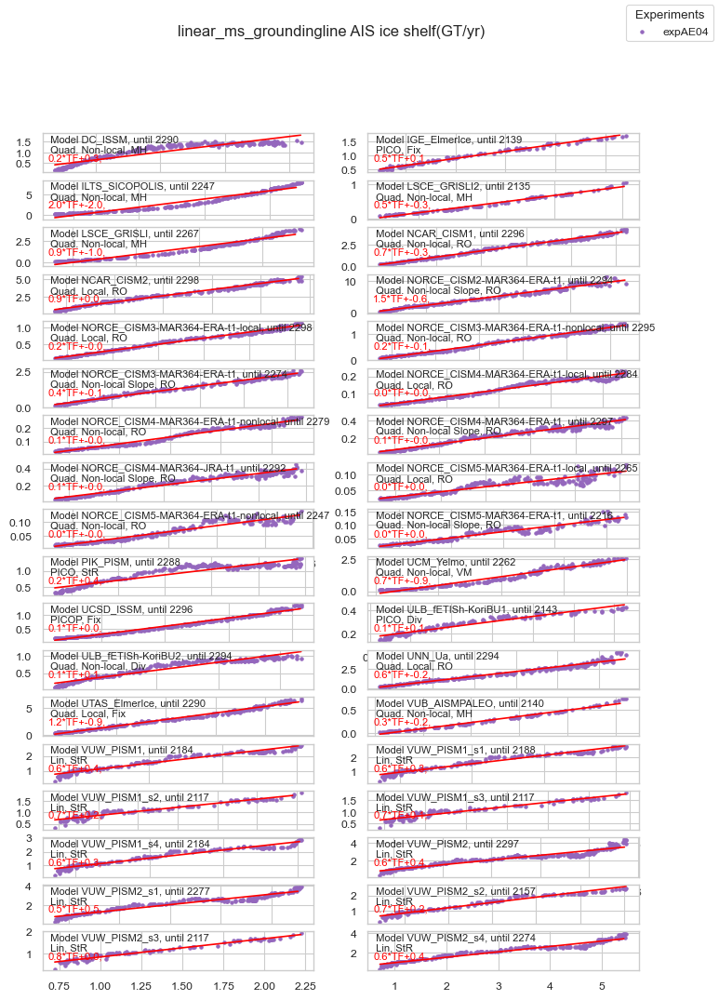

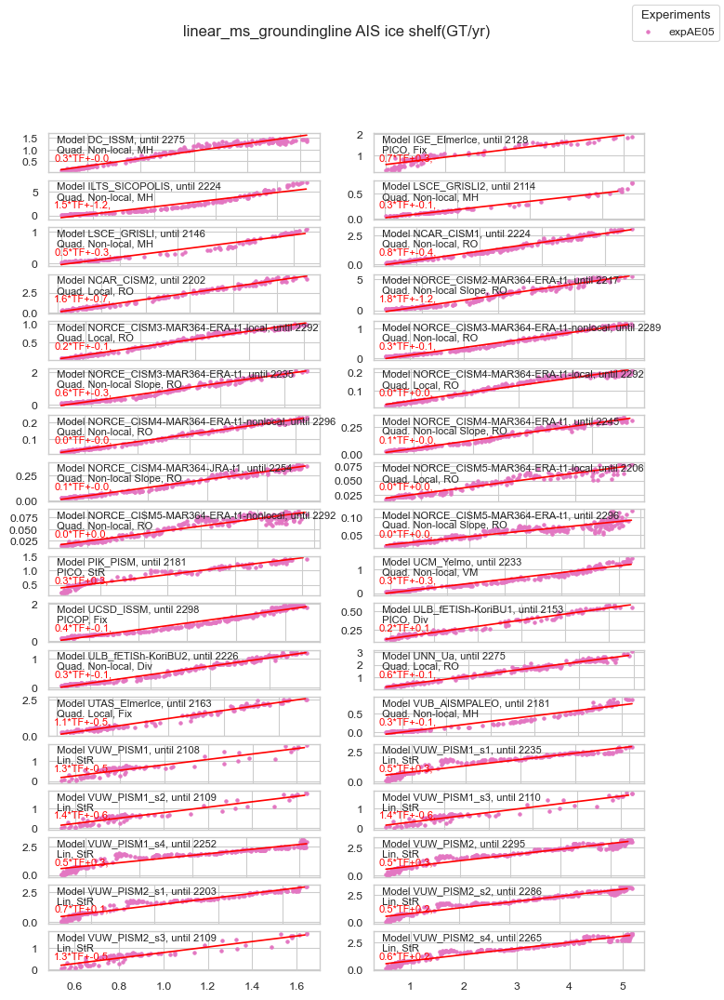

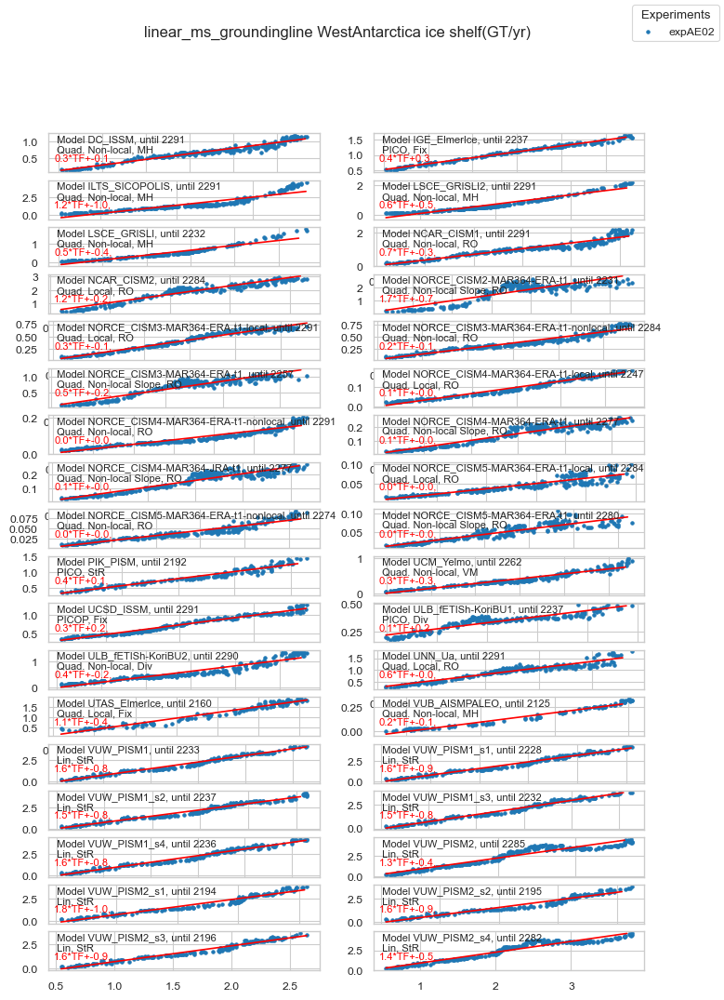

...

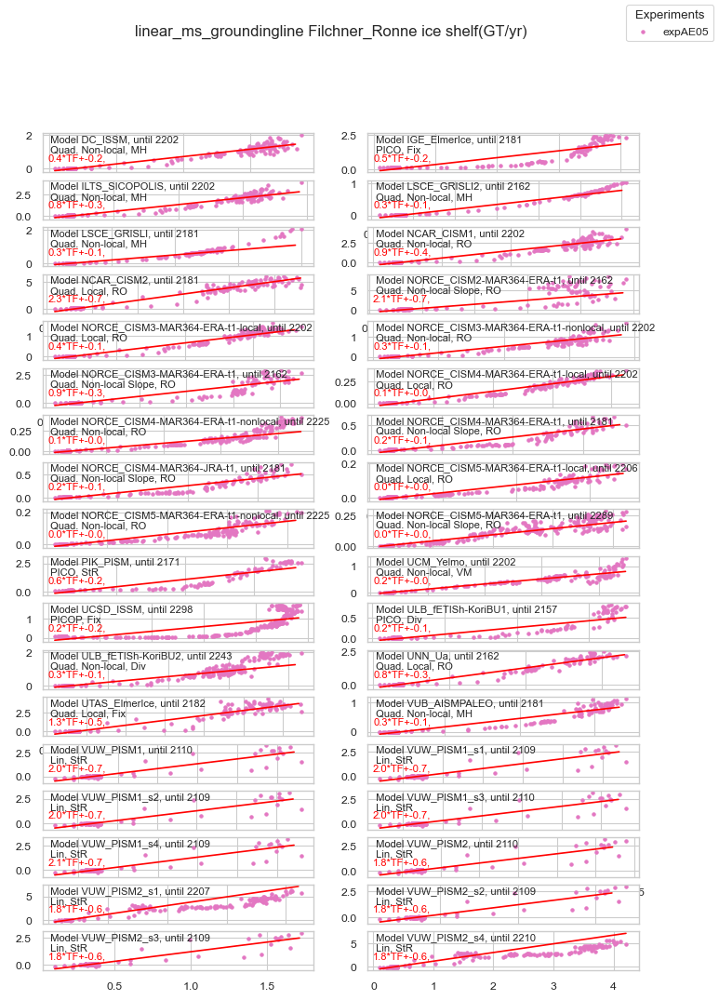

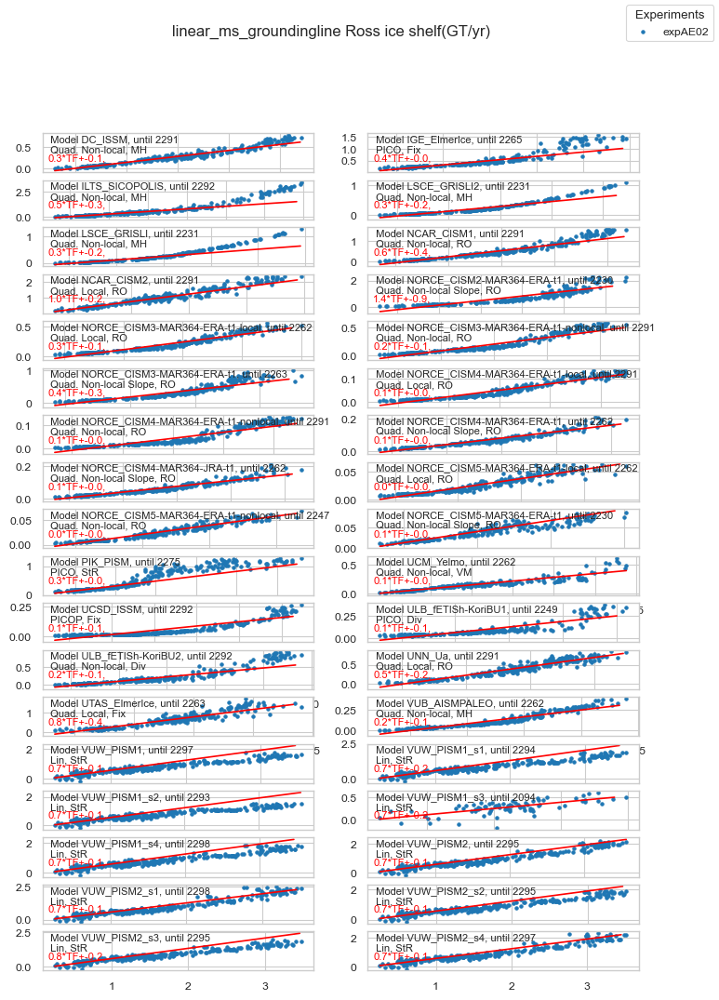

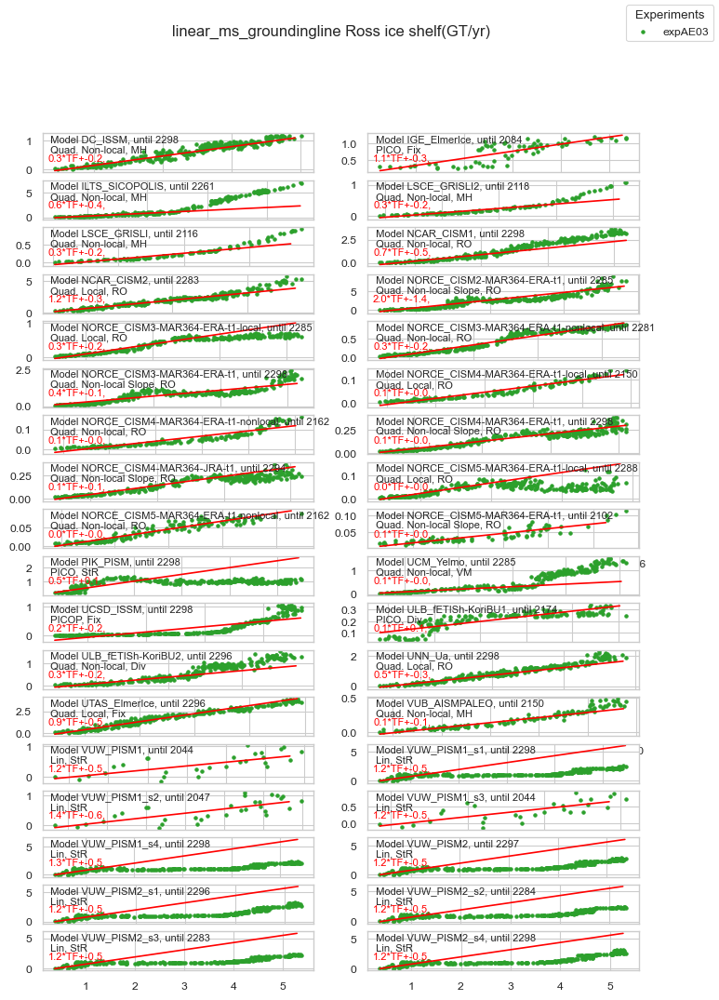

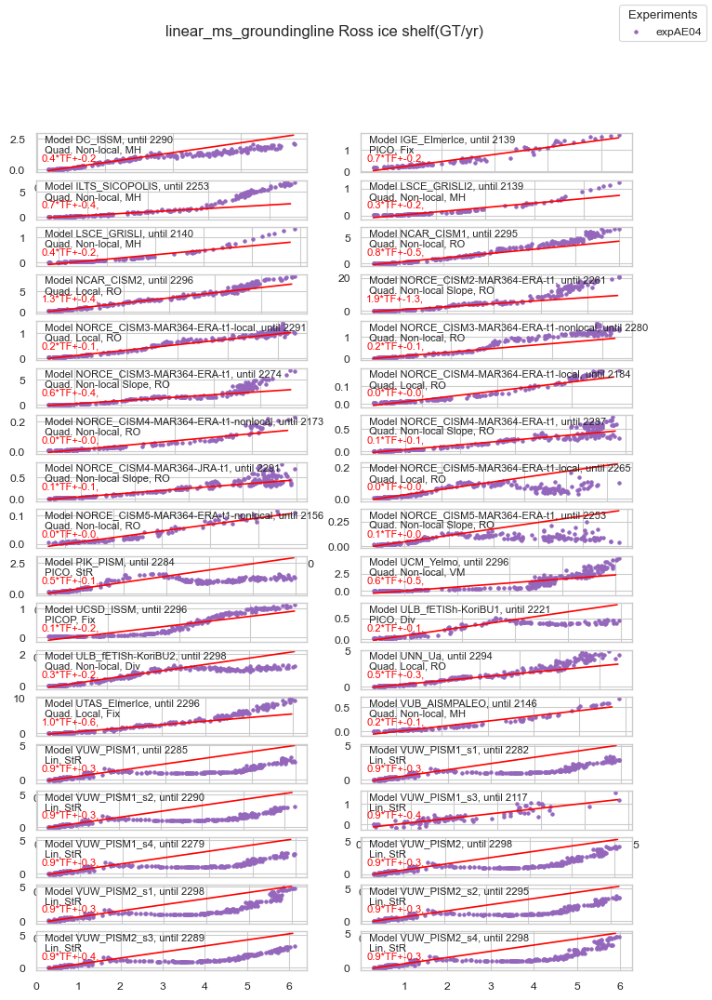

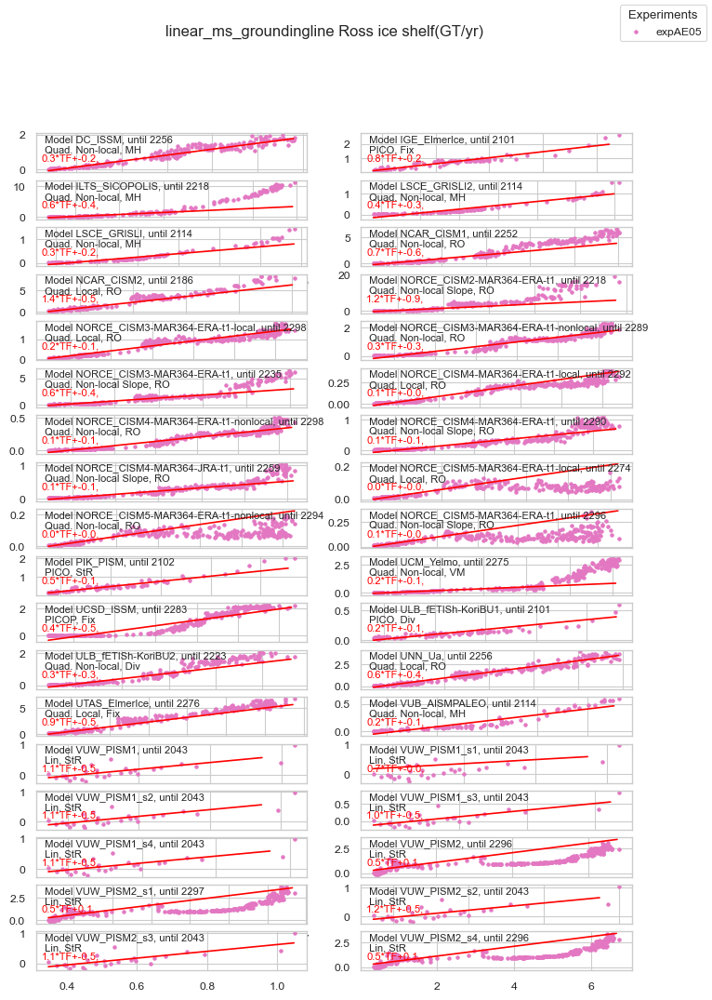

In [23]:
for key in dic_area_of_interest.keys():

  
    lst = dic_area_of_interest[key]

    a4_width = 8.27  # inches
    a4_height = 11.69
    colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
    fs = 8


    for j,exp in enumerate(expnames):
        f,ax = plt.subplots(df.shape[0]//2,2,figsize=(a4_width, a4_height))
        
        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        ms_exp =df_ms[df_ms['Experiment']== exp].reset_index(drop=True)
        ms_n_exp =df_ms_n[df_ms_n['Experiment']== exp].reset_index(drop=True)
        df_time_exp = df_time[df_time['Experiment']== exp].reset_index(drop = True)

        for i in range (df.shape[0]):
   
            ix =i //2
            iy=i%2
        

            #load the datasets:
            pth_way = f'{pth}/{df.iloc[i].Experiment}/groundingline_corridor32/computed_{variable2}_corr_32_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'

            pth_area =  f'{pth}/{df.iloc[i].Experiment}/groundingline_corridor32/computed_{variable3}_corr_32_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
            pth_tf = f'{pth}/{df.iloc[i].Experiment}/groundingline_corridor32/computed_{variable1}_corr_32_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'

            # Melting
            d = xr.open_dataset(pth_way,decode_times=False )
            # Area
            d2 = xr.open_dataset(pth_area,decode_times=False )
            #thermal forcing 
            d3 = xr.open_dataset(pth_tf,decode_times=False )
    



            t_max2 = df_time_exp.iloc[i][key]
         
            t_max3=2298
           
            
            t_max = np.min([ t_max2 , t_max3 ])
          

    
            tmin =np.where( d.time.values>=t_max)[0][0]
       
            
            if tmin <10:
                print(df.iloc[i].Model)
            
        
             
           
           
            #melting per area
            the_ys = np.zeros((len(dic_area_of_interest[key]),tmin))
            the_areas = np.zeros((len(dic_area_of_interest[key]),tmin))
            the_tfs = np.zeros((len(dic_area_of_interest[key]),tmin))
            
            
          
            for k,nm in enumerate(lst):
             

                the_ys[k,:] =d[f'{variable2}{nm}'].values[:tmin].copy()*factor
        
                the_areas[k,:]=d2[f'{variable3}{nm}'].values[:tmin].copy()
            
                the_tfs[k,:]=d3[f'{variable1}{nm}'].values[:tmin].copy()*the_areas[k,:].copy()
                
                

            y = np.sum(the_ys ,axis =0)
            area = np.sum( the_areas,axis = 0)
            TF = np.sum( the_tfs,axis = 0)/area
            TF_even = np.arange(np.nanmin(TF),np.nanmax(TF),0.1)
             
            ms = ms_exp.iloc[i][key]
 
            ms_n = ms_n_exp.iloc[i][key]
            
            ax2 = ax[ix,iy]
            ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
            ax2.plot(TF_even,ms*TF_even+ms_n,color = 'red')
            
           
            
            
            df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
            df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
            meltparam =  df_info_model_exp['Melt parameterisation'].values[0]
            icefront =  df_info_model_exp['ice front'].values[0]

            ax2.text(0.02, 0.98,f' Model {df.iloc[i].Model}, until {t_max} \n {meltparam}, {icefront}',transform=ax2.transAxes,fontsize = fs, va='top')
            ax2.text(0.02, 0.5,f'{np.round(ms,1)}*TF+{np.round(ms_n,1)},',transform=ax2.transAxes,fontsize = fs, va='top',color = 'red')
  
        handles, labels = ax[0, 0].get_legend_handles_labels()
        f.legend(handles, labels, loc='upper right', title='Experiments')
     

        f.suptitle(f'{fname} {key} ice shelf(GT/yr)',fontsize = 12)
        f.savefig(f'{fpath}{fname}_{key}_{exp}.pdf')
       


In [ ]:
handles